In [1]:
import qiskit, qiskit_aer, qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("QML:", qiskit_machine_learning.__version__)

Qiskit: 1.4.4
Aer: 0.17.2
QML: 0.8.4


In [2]:
# To ensure reproducibility of results
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 12345

In [3]:
# Imports
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, classification_report, balanced_accuracy_score
from scipy.stats import chi2_contingency

In [4]:
# --- Qiskit Imports ---
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [5]:
lung_cancer_column_names = ['label'] + [f'attr_{i}' for i in range(1, 57)]
# file_path_lung = '/content/sample_data/lung-cancer.data'
# file_path_lung = '/kaggle/input/lungcancer-qsvm/lung-cancer.data'
file_path_lung = r'C:\Users\User\Documents\MyProjects\AI_Projects\quantum-svm-generalization-study\data\lung+cancer\lung-cancer.data'

# Read data, treating "?" as missing values
df_lung = pd.read_csv(file_path_lung, header=None, names=lung_cancer_column_names, na_values=['?'])

print(f"Original shape of Lung Cancer data: {df_lung.shape}")
print(f"Missing values: {df_lung.isnull().sum().sum()}")

Original shape of Lung Cancer data: (32, 57)
Missing values: 5


In [6]:
# Mode imputation for missing values
modes = df_lung.mode().iloc[0]
df_lung.fillna(modes, inplace=True)

# Then check if all Nan are gon
print(f"Total missing values after imputation: {df_lung.isnull().sum().sum()}\n")

Total missing values after imputation: 0



In [7]:
# Target Binarization
df_lung['label_binary'] = df_lung['label'].apply(lambda x: 0 if x == 1 else 1)

In [8]:
experiments = [
    # --- EXP 1: Dimensionality Effect (Quantum Complexity) ---
    {'id': 'Exp1_2feat',   'no_features': 2,  'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_4feat',   'no_features': 4,  'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_6feat',   'no_features': 6,  'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_8feat',   'no_features': 8,  'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_10feat',  'no_features': 10, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp1_15feat',  'no_features': 15, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},

    # --- EXP 2: Shot Noise Effect (Measurement Precision) ---
    {'id': 'Exp2_128shots',  'no_features': 8, 'shots': 128,  'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_256shots',  'no_features': 8, 'shots': 256,  'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_512shots',  'no_features': 8, 'shots': 512,  'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp2_1024shots', 'no_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},

    # --- EXP 3: Reps Effect (Circuit Complexity) ---
    {'id': 'Exp3_Reps1', 'no_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp3_Reps2', 'no_features': 8, 'shots': 1024, 'reps': 2, 'entanglement': 'linear'},
    {'id': 'Exp3_Reps3', 'no_features': 8, 'shots': 1024, 'reps': 3, 'entanglement': 'linear'},

    # --- EXP 4: Entanglement Ablation ---
    {'id': 'Exp4_Linear',   'no_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear'},
    {'id': 'Exp4_Circular', 'no_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'circular'},
    {'id': 'Exp4_Full',     'no_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'full'},
]


In [9]:
# ==========================================
# MAIN EXPERIMENT LOOP
# ==========================================

# Store all results
all_results = []

# Separate Features & Target
X_lung = df_lung.drop(['label', 'label_binary'], axis=1)
y_lung_binary = df_lung['label_binary']

for exp_num, config in enumerate(experiments, 1):
    print("\n" + "=" * 80)
    print(f"EXPERIMENT {exp_num}/{len(experiments)}: {config['id']}")
    print("=" * 80)
    samples = config.get("samples", "ALL")
    print(f"  Samples: {samples}")
    print(f"  K Features: {config['no_features']}")
    print(f"  Shots: {config['shots']}")
    print(f"  Reps: {config['reps']}")
    print(f"  Entanglement: {config['entanglement']}")
    print("=" * 80)

    # ===================================================================
    # 1. CREATE DATASET BASED ON SAMPLE SIZE
    # ===================================================================

    train_samples = config.get("samples", None)

    if train_samples is not None:
        subset_size = int(round(train_samples / 0.7))
    else:
        subset_size = None  # means use full dataset

    X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
      X_lung, y_lung_binary, test_size=0.3, random_state=42, stratify=y_lung_binary
    )

    print(f"Training samples: {X_train_lc.shape[0]}")
    print(f"Test samples: {X_test_lc.shape[0]}\n")

    # ===================================================================
    # 2. ONE-HOT ENCODING
    # ===================================================================

    # One-Hot Encoding
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_lc_encoded = pd.DataFrame(
        encoder.fit_transform(X_train_lc),
        columns=encoder.get_feature_names_out()
    )
    X_test_lc_encoded = pd.DataFrame(
        encoder.transform(X_test_lc),
        columns=encoder.get_feature_names_out()
    )

    print(f"Encoded features: {X_train_lc_encoded.shape[1]}")

    # ===================================================================
    # 3. FEATURE SELECTION - CRAMER'S V
    # ===================================================================

    # Feature Selection - Cramer's V
    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        if min((kcorr-1), (rcorr-1)) == 0: return 0
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

    cramers_scores = {col: cramers_v(X_train_lc_encoded[col], y_train_lc) for col in X_train_lc_encoded.columns}
    cramers_series = pd.Series(cramers_scores).sort_values(ascending=False)

    N_FEATURES_TO_SELECT = config['no_features']
    top_features = cramers_series.head(N_FEATURES_TO_SELECT).index.tolist()

    X_train_lc_final = X_train_lc_encoded[top_features]
    X_test_lc_final = X_test_lc_encoded[top_features]

    print("--- Data Preprocessing Complete ---")
    print(f"Final training data shape: {X_train_lc_final.shape}")
    print(f"Final testing data shape: {X_test_lc_final.shape}\n")

    # ===================================================================
    # 4. QUANTUM KERNEL SETUP
    # ===================================================================

    fm = ZZFeatureMap(
        feature_dimension=config['no_features'],
        reps=config['reps'],
        entanglement=config['entanglement']
    )

    sampler = Sampler(default_shots=config['shots'])
    fidelity = ComputeUncompute(sampler=sampler)
    qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm)

    print(f"Quantum kernel configured (ZZFeatureMap, reps={config['reps']}, entanglement={config['entanglement']})")

    # ===================================================================
    # 5. COMPUTE KERNEL MATRICES
    # ===================================================================

    print("\nComputing kernel matrices...")
    start_kernel = time.time()

    matrix_train = qkernel.evaluate(x_vec=X_train_lc_final)
    matrix_test = qkernel.evaluate(x_vec=X_test_lc_final, y_vec=X_train_lc_final)

    kernel_time = time.time() - start_kernel
    print(f"Kernel computation: {kernel_time:.2f}s")

    # ===================================================================
    # 6. GRID SEARCH
    # ===================================================================

    print("\nGrid searching for optimal C...")
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'),
        param_grid,
        cv=cv,
        scoring='accuracy',
        verbose=0,
        n_jobs=-1
    )

    start_train = time.time()
    grid_search.fit(matrix_train, y_train_lc)
    train_time = time.time() - start_train

    best_model = grid_search.best_estimator_
    best_c = grid_search.best_params_['C']
    cv_score = grid_search.best_score_

    print(f"  → Best C: {best_c}")
    print(f"  → CV Score: {cv_score:.4f}")
    print(f"  → Training time: {train_time:.2f}s")

    # ===================================================================
    # 7. EVALUATION
    # ===================================================================

    y_train_pred = best_model.predict(matrix_train)
    y_test_pred = best_model.predict(matrix_test)

    train_accuracy = accuracy_score(y_train_lc, y_train_pred)
    test_accuracy = accuracy_score(y_test_lc, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test_lc, y_test_pred)
    spam_recall = recall_score(y_test_lc, y_test_pred, pos_label=1)
    generalization_gap = abs(train_accuracy - test_accuracy)

    print(f" → Train Accuracy: {train_accuracy:.4f}")
    print(f" → Test Accuracy: {test_accuracy:.4f}")
    print(f" → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f" → Spam Recall: {spam_recall:.4f}")
    print(f" → Generalization Gap: {generalization_gap:.4f}")

    # ===================================================================
    # 8. STORE RESULTS
    # ===================================================================

    all_results.append({
        'experiment_id': config['id'],
        'exp_number': exp_num,
        'samples': config.get('samples', 'ALL'),
        'no_features': config['no_features'],
        'shots': config['shots'],
        'reps': config['reps'],
        'entanglement': config['entanglement'],
        'selected_features': top_features,
        'best_c': best_c,
        'cv_score': cv_score,
        'train_acc': train_accuracy,
        'test_acc': test_accuracy,
        'test_balanced_acc': test_balanced_acc,
        'spam_recall': spam_recall,
        'generalization_gap': generalization_gap,  # Added missing comma
        'kernel_time': kernel_time,
        'train_time': train_time
    })

    # Print classification report
    print("\n" + "Classification Report:")
    print(classification_report(y_test_lc, y_test_pred, zero_division=0))



EXPERIMENT 1/16: Exp1_2feat
  Samples: ALL
  K Features: 2
  Shots: 1024
  Reps: 1
  Entanglement: linear
Training samples: 22
Test samples: 10

Encoded features: 153
--- Data Preprocessing Complete ---
Final training data shape: (22, 2)
Final testing data shape: (10, 2)

Quantum kernel configured (ZZFeatureMap, reps=1, entanglement=linear)

Computing kernel matrices...
Kernel computation: 8.13s

Grid searching for optimal C...
  → Best C: 1
  → CV Score: 0.5893
  → Training time: 19.35s
 → Train Accuracy: 0.5000
 → Test Accuracy: 0.4000
 → Test Balanced Accuracy: 0.4762
 → Spam Recall: 0.2857
 → Generalization Gap: 0.1000

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.67      0.40         3
           1       0.67      0.29      0.40         7

    accuracy                           0.40        10
   macro avg       0.48      0.48      0.40        10
weighted avg       0.55      0.40      0.40        10


EXPERIMENT 2/16:


--- Plotting Exp1: Effect of Feature Dimension (Qubits) ---


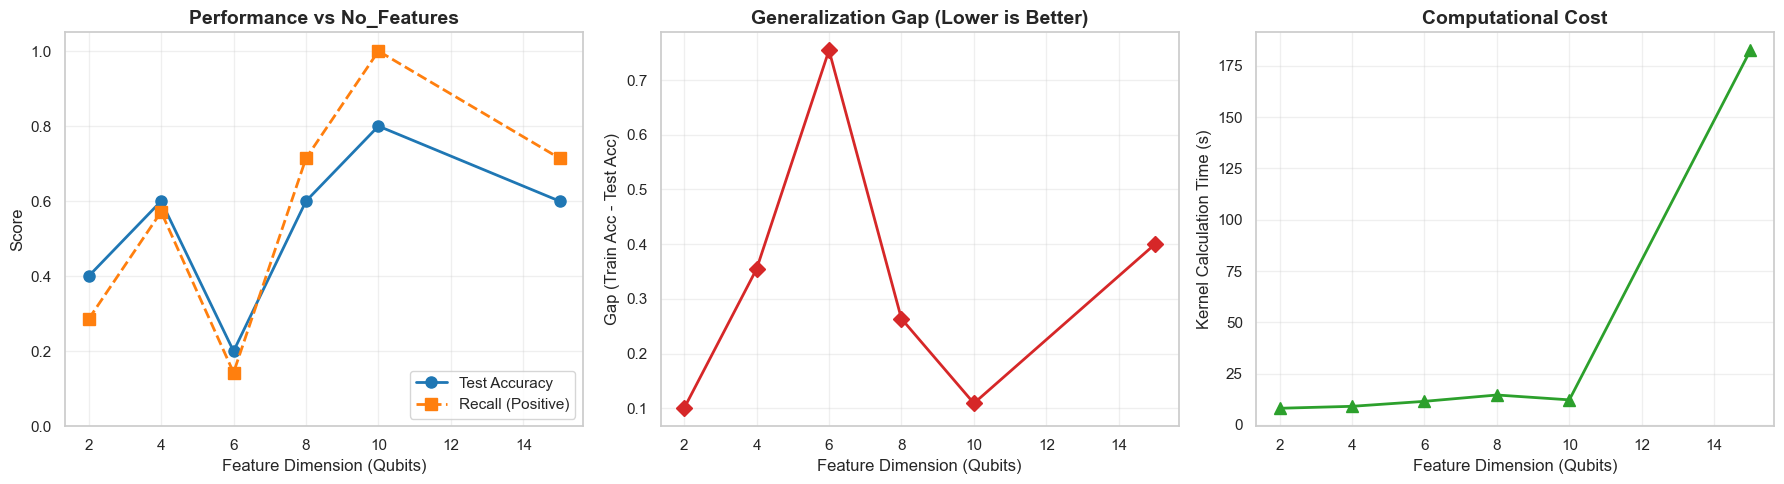


--- Plotting Exp2: Effect of Shots (Measurement) ---


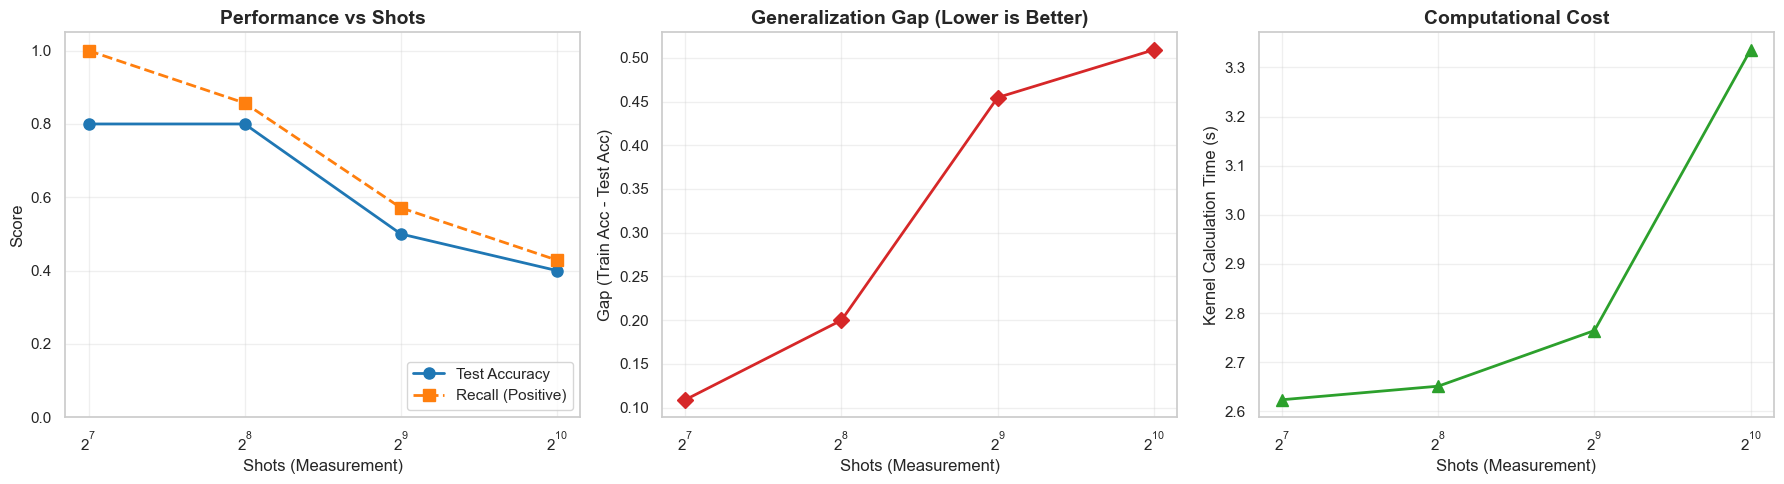


--- Plotting Exp3: Effect of Circuit Depth (Reps) ---


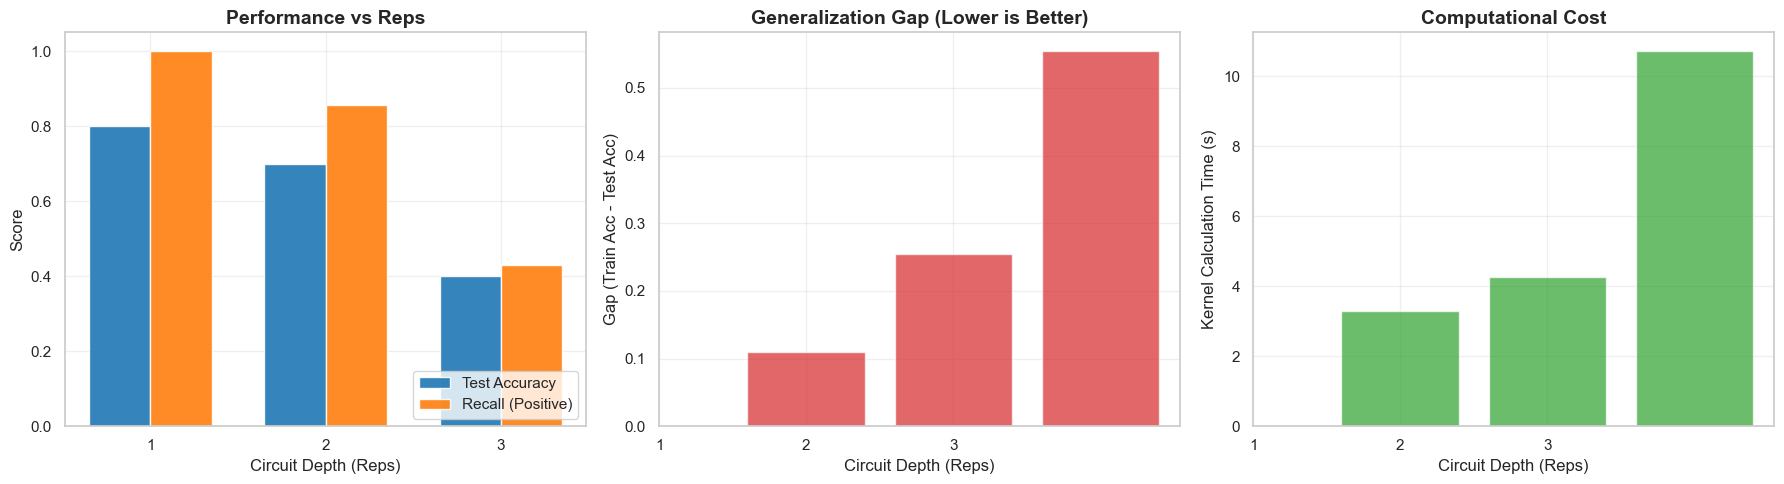


--- Plotting Exp4: Effect of Entanglement Type ---


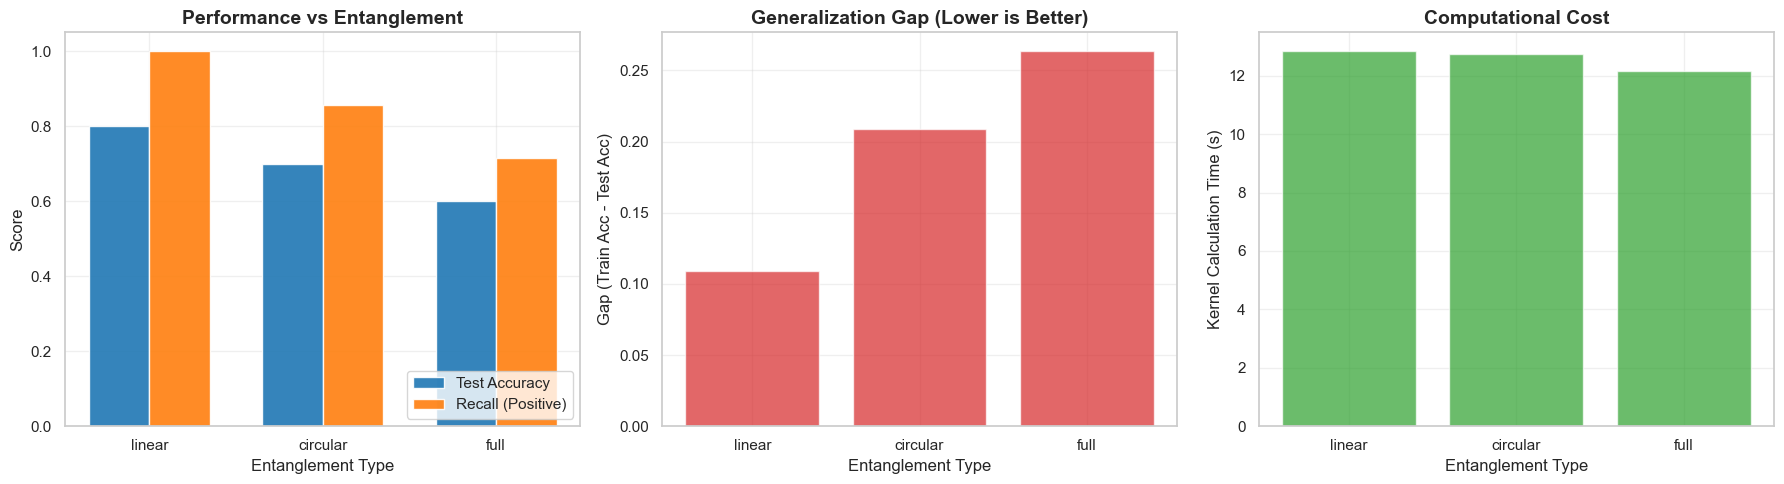


--- Global Performance Overview ---


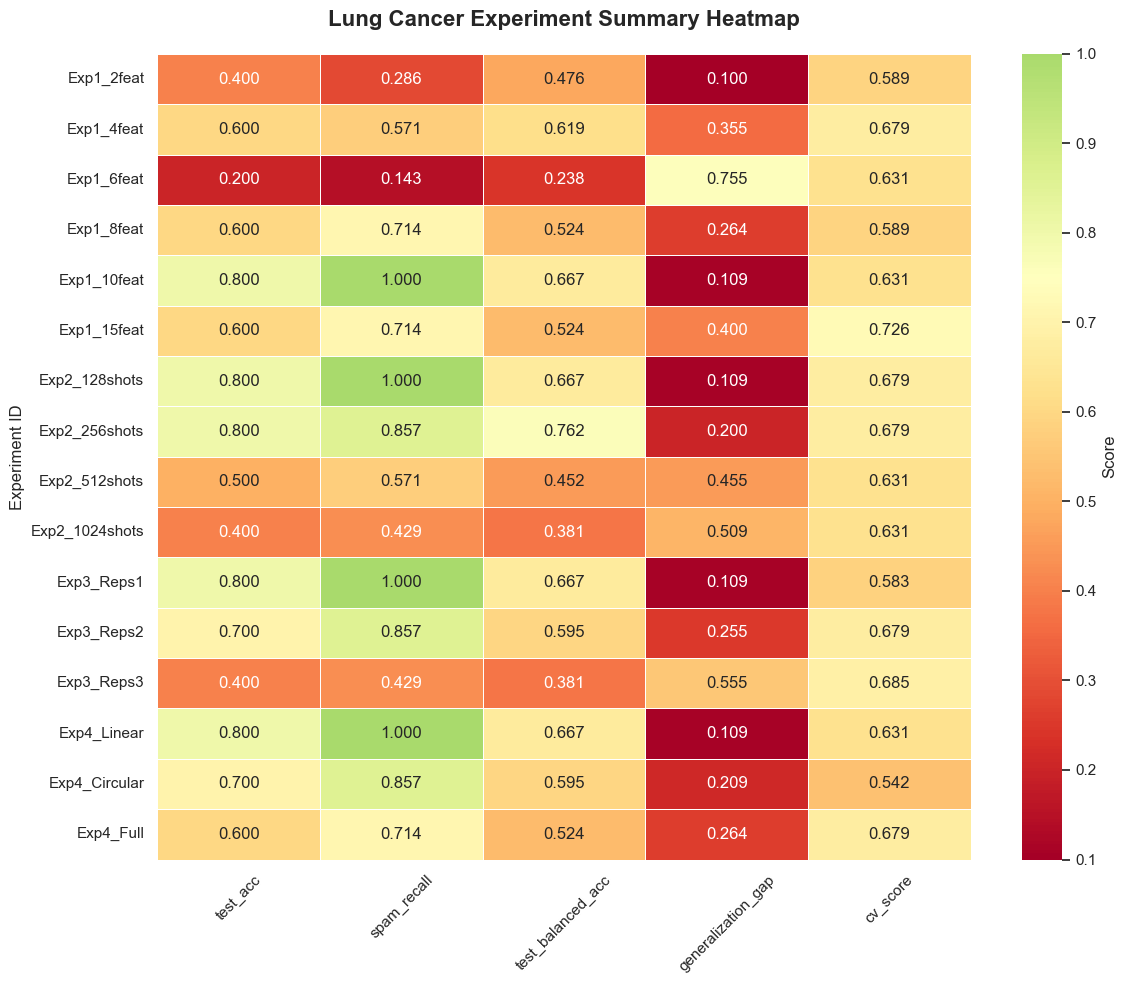

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# CONFIGURATION & STYLE
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8

def plot_lungcancer_consistent(df):
    """
    Generates standardized visualizations for Lung Cancer QSVM experiments.
    """
    
    # Map Experiment IDs to the parameter being varied
    # Note: Lung Cancer starts with Features (Exp1), unlike Spambase which started with Samples
    exp_map = {
        'Exp1': {'param': 'no_features',  'xlabel': 'Feature Dimension (Qubits)', 'log_x': False, 'type': 'line'},
        'Exp2': {'param': 'shots',        'xlabel': 'Shots (Measurement)',        'log_x': True,  'type': 'line'},
        'Exp3': {'param': 'reps',         'xlabel': 'Circuit Depth (Reps)',       'log_x': False, 'type': 'bar'},
        'Exp4': {'param': 'entanglement', 'xlabel': 'Entanglement Type',          'log_x': False, 'type': 'bar'}
    }

    # Iterate through each defined experiment group
    for group_key, config in exp_map.items():
        # 1. Filter data for this experiment group
        subset = df[df['experiment_id'].str.contains(group_key)].copy()
        
        if subset.empty:
            continue
            
        param = config['param']
        
        # Sort by parameter to ensure line plots are ordered correctly
        if config['type'] == 'line':
            subset = subset.sort_values(by=param)
            
        print(f"\n--- Plotting {group_key}: Effect of {config['xlabel']} ---")
        
        fig, axes = plt.subplots(1, 3)
        
        # -------------------------------------------------------
        # SUBPLOT 1: PERFORMANCE (Accuracy vs Recall)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            x_pos = np.arange(len(subset))
            width = 0.35
            # Plot bars
            axes[0].bar(x_pos - width/2, subset['test_acc'], width, label='Test Accuracy', color='#1f77b4', alpha=0.9)
            axes[0].bar(x_pos + width/2, subset['spam_recall'], width, label='Recall (Positive)', color='#ff7f0e', alpha=0.9)
            axes[0].set_xticks(x_pos)
            axes[0].set_xticklabels(subset[param])
        else:
            # Plot lines
            axes[0].plot(subset[param], subset['test_acc'], 'o-', label='Test Accuracy', color='#1f77b4')
            axes[0].plot(subset[param], subset['spam_recall'], 's--', label='Recall (Positive)', color='#ff7f0e')
            if config['log_x']: axes[0].set_xscale('log', base=2)

        axes[0].set_xlabel(config['xlabel'])
        axes[0].set_ylabel('Score')
        axes[0].set_title(f'Performance vs {config["param"].title()}')
        axes[0].set_ylim(0, 1.05)
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)

        # -------------------------------------------------------
        # SUBPLOT 2: GENERALIZATION GAP (Overfitting)
        # -------------------------------------------------------
        # Note: Your results dict key is 'generalization_gap', make sure it matches
        gen_gap_col = 'generalization_gap' if 'generalization_gap' in subset.columns else 'gen_gap'
        
        if config['type'] == 'bar':
            axes[1].bar(subset[param], subset[gen_gap_col], color='#d62728', alpha=0.7)
            axes[1].set_xticks(range(len(subset)))
            axes[1].set_xticklabels(subset[param])
        else:
            axes[1].plot(subset[param], subset[gen_gap_col], 'D-', color='#d62728')
            if config['log_x']: axes[1].set_xscale('log', base=2)
            
        axes[1].set_xlabel(config['xlabel'])
        axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
        axes[1].set_title('Generalization Gap (Lower is Better)')
        axes[1].grid(True, alpha=0.3)

        # -------------------------------------------------------
        # SUBPLOT 3: COMPUTATIONAL COST (Time)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            axes[2].bar(subset[param], subset['kernel_time'], color='#2ca02c', alpha=0.7)
            axes[2].set_xticks(range(len(subset)))
            axes[2].set_xticklabels(subset[param])
        else:
            axes[2].plot(subset[param], subset['kernel_time'], '^-', color='#2ca02c')
            if config['log_x']: axes[2].set_xscale('log', base=2)

        axes[2].set_xlabel(config['xlabel'])
        axes[2].set_ylabel('Kernel Calculation Time (s)')
        axes[2].set_title('Computational Cost')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------
    # SUMMARY HEATMAP
    # -------------------------------------------------------
    print("\n--- Global Performance Overview ---")
    plt.figure(figsize=(12, 10))
    
    # Handle potentially different column names
    gen_gap_col = 'generalization_gap' if 'generalization_gap' in df.columns else 'gen_gap'
    metrics = ['test_acc', 'spam_recall', 'test_balanced_acc', gen_gap_col, 'cv_score']
    
    # Prepare data
    heatmap_data = df.set_index('experiment_id')[metrics]
    
    # Plot
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0.75, linewidths=.5, cbar_kws={'label': 'Score'})
    
    plt.title('Lung Cancer Experiment Summary Heatmap', fontsize=16, pad=20)
    plt.ylabel('Experiment ID')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
# Convert list of dicts (all_results) to DataFrame first
results_df_lung = pd.DataFrame(all_results)

# Run the visualization
plot_lungcancer_consistent(results_df_lung)
